# Loan Default Risk Prediction Using Machine Learning

Business Analytics Project using the UCI Statlog German Credit dataset.

## 1. Business Problem
Banks need to assess whether a loan applicant represents a relatively good or bad credit risk. The objective is to build a binary classification model and provide an actionable risk recommendation.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


In [66]:
dataset = fetch_ucirepo(id=144)
X = dataset.data.features.copy()
y = dataset.data.targets.copy()
print('Features:', X.shape)
print('Target:', y.shape)
X.head()
print(X.columns.tolist())


Features: (1000, 20)
Target: (1000, 1)
['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']


## 2. Data Preparation
The original target is converted to binary format: 0 = good/non-default and 1 = bad/default. Numerical and categorical variables are handled through a preprocessing pipeline.

In [57]:
X.columns = [f'feature_{i+1}' for i in range(X.shape[1])]
target = pd.to_numeric(y.iloc[:,0], errors='coerce').map({1:0, 2:1})
print(target.value_counts())


class
0    700
1    300
Name: count, dtype: int64


In [58]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
print('Numeric:', numeric_features)
print('Categorical:', categorical_features)


Numeric: ['feature_2', 'feature_5', 'feature_8', 'feature_11', 'feature_13', 'feature_16', 'feature_18']
Categorical: ['feature_1', 'feature_3', 'feature_4', 'feature_6', 'feature_7', 'feature_9', 'feature_10', 'feature_12', 'feature_14', 'feature_15', 'feature_17', 'feature_19', 'feature_20']


## 3. Exploratory Data Analysis

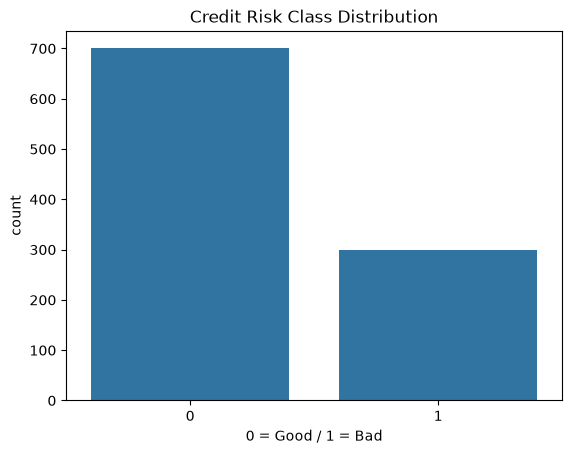

In [59]:
sns.countplot(x=target)
plt.title('Credit Risk Class Distribution')
plt.xlabel('0 = Good / 1 = Bad')
plt.show()


In [60]:
num_view = X.select_dtypes(include=['int64','float64'])
num_view.describe().T


,count,mean,std,min,25%,50%,75%,max
feature_2,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
feature_5,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
feature_8,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
feature_11,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
feature_13,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
feature_16,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
feature_18,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


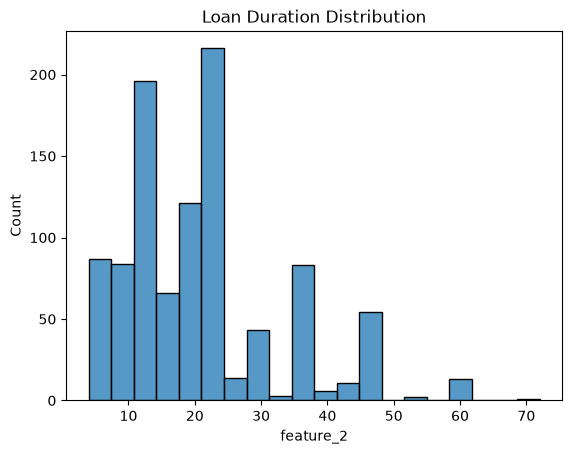

In [61]:
if 'feature_2' in X.columns:
    sns.histplot(data=X, x='feature_2', bins=20)
    plt.title('Loan Duration Distribution')
    plt.show()


## 4. Model Building
Two models are compared: Logistic Regression and Random Forest. The preprocessing steps are placed inside each pipeline.

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.20, random_state=42, stratify=target
)
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
pre = ColumnTransformer([('num', num_pipe, numeric_features), ('cat', cat_pipe, categorical_features)])


In [64]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42, class_weight='balanced')
}
results = {}
for name, clf in models.items():
    pipe = Pipeline([('preprocessor', pre), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:,1]
    results[name] = {
        'Accuracy': accuracy_score(y_test,pred),
        'Precision': precision_score(y_test,pred,zero_division=0),
        'Recall': recall_score(y_test,pred,zero_division=0),
        'F1': f1_score(y_test,pred,zero_division=0),
        'ROC-AUC': roc_auc_score(y_test,prob)
    }
pd.DataFrame(results).T


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.750,0.558140,0.8,0.657534,0.805833
Random Forest,0.725,0.531646,0.7,0.604317,0.794643


## 5. Business Interpretation
Recall is important because a false negative can mean approving a genuinely high-risk applicant. ROC-AUC is used as the primary model-selection criterion, with recall considered as a secondary business objective.

## 6. Streamlit Deployment
Run `python train_model.py` to create the trained model, then run `streamlit run app.py` to launch the interactive application.

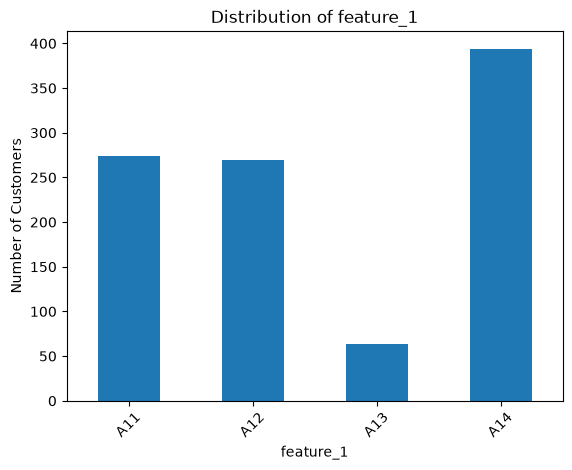

In [65]:
import matplotlib.pyplot as plt

feature = X.columns[0]

X.groupby(feature).size().plot(kind="bar")
plt.title("Distribution of " + feature)
plt.xlabel(feature)
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [67]:
print(X.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Attribute1   1000 non-null   str  
 1   Attribute2   1000 non-null   int64
 2   Attribute3   1000 non-null   str  
 3   Attribute4   1000 non-null   str  
 4   Attribute5   1000 non-null   int64
 5   Attribute6   1000 non-null   str  
 6   Attribute7   1000 non-null   str  
 7   Attribute8   1000 non-null   int64
 8   Attribute9   1000 non-null   str  
 9   Attribute10  1000 non-null   str  
 10  Attribute11  1000 non-null   int64
 11  Attribute12  1000 non-null   str  
 12  Attribute13  1000 non-null   int64
 13  Attribute14  1000 non-null   str  
 14  Attribute15  1000 non-null   str  
 15  Attribute16  1000 non-null   int64
 16  Attribute17  1000 non-null   str  
 17  Attribute18  1000 non-null   int64
 18  Attribute19  1000 non-null   str  
 19  Attribute20  1000 non-null   str  
dtypes: int64(7), str(13)

In [68]:
print(X.head().to_string())

  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6 Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18 Attribute19 Attribute20
0        A11           6        A34        A43        1169        A65        A75           4        A93        A101            4        A121           67        A143        A152            2        A173            1        A192        A201
1        A12          48        A32        A43        5951        A61        A73           2        A92        A101            2        A121           22        A143        A152            1        A173            1        A191        A201
2        A14          12        A34        A46        2096        A61        A74           2        A93        A101            3        A121           49        A143        A152            1        A172            2        A191        A201
3        A11          42        A32     